In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Imports from your project structure
from modules.forecasting.data.preprocess_coin import CoinPreprocessor  
from modules.forecasting.models.prophet import ProphetModel  
from modules.forecasting.data.preprocess_utils import load_scaler_with_meta, _scaler_path_for

# --- CONFIG ---
PROPHET_BASE_DIR = Path("src/modules/forecasting/models/saved/prophet")
SYMBOL = "BTC"  
EXCHANGE = "binance"
INTERVAL = "1h"
FORECAST_STEPS = 168  # 7 Days ahead

# Load Data
print(f"Loading Data for {SYMBOL}")
coin_pre = CoinPreprocessor() 
df_recent = coin_pre.load_features_series(SYMBOL, exchange=EXCHANGE, interval=INTERVAL)

# We need enough data for a good plot, let's take the last 1000 hours
df_recent = df_recent.tail(1000).copy()

c:\Users\sarfras\anaconda3\envs\novum\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Data for BTC


In [2]:
# CRITICAL: INVERSE SCALING (Convert 0-1 back to Real Price)
print("--- Inverse Scaling Data ---")
scaler_path = _scaler_path_for(coin_pre.scaler_dir, SYMBOL, None)
scaler, cols = load_scaler_with_meta(scaler_path)

if scaler and 'close' in cols:
    # Create a matrix of zeros to match the scaler's expected shape
    matrix = np.zeros((len(df_recent), len(cols)))
    
    # Fill in the columns we have
    for i, c in enumerate(cols):
        if c in df_recent.columns:
            matrix[:, i] = df_recent[c].values
    
    # Inverse transform
    close_idx = cols.index('close')
    real_close_prices = scaler.inverse_transform(matrix)[:, close_idx]
    
    # Replace the scaled 'close' with the real 'close'
    df_recent['close'] = real_close_prices
    print(f"Last Real Price: {df_recent['close'].iloc[-1]:.2f}")
else:
    print("WARNING: Could not load scaler. Data might be 0-1 scaled.")

--- Inverse Scaling Data ---


In [3]:
# Setup Model
promodel = ProphetModel(
    symbol=SYMBOL,
    model_dir=str(PROPHET_BASE_DIR),
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,
    holidays_prior_scale=10.0,
    changepoint_range=0.9
)

#  Load or Train
promodel_path = PROPHET_BASE_DIR / f"prophet_{SYMBOL}.pkl"

# Note: For a sanity check, it's often better to force a quick retrain 
# to ensure it fits the REAL data we just prepared, not old scaled data.
print("--- Training Model on Real Prices ---")
promodel.train(df_recent, target_col='close')
# promodel.save() # Optional: Don't overwrite if just testing

--- Training Model on Real Prices ---


12:10:00 - cmdstanpy - INFO - Chain [1] start processing
12:10:01 - cmdstanpy - INFO - Chain [1] done processing


In [4]:
# Forecast
print(f"--- Forecasting {FORECAST_STEPS} hours ahead ---")
forecast = promodel.forecast(steps=FORECAST_STEPS, freq='h')
# Print numbers
print("\nNext 5 Hours Prediction:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head(5))

--- Forecasting 168 hours ahead ---

Next 5 Hours Prediction:
                      ds      yhat  yhat_lower  yhat_upper
1000 2025-11-19 15:00:00  0.391353    0.279414    0.501097
1001 2025-11-19 16:00:00  0.400139    0.289316    0.505303
1002 2025-11-19 17:00:00  0.405205    0.297406    0.512966
1003 2025-11-19 18:00:00  0.404404    0.292768    0.511716
1004 2025-11-19 19:00:00  0.399455    0.288993    0.513998


--- Plotting Results ---


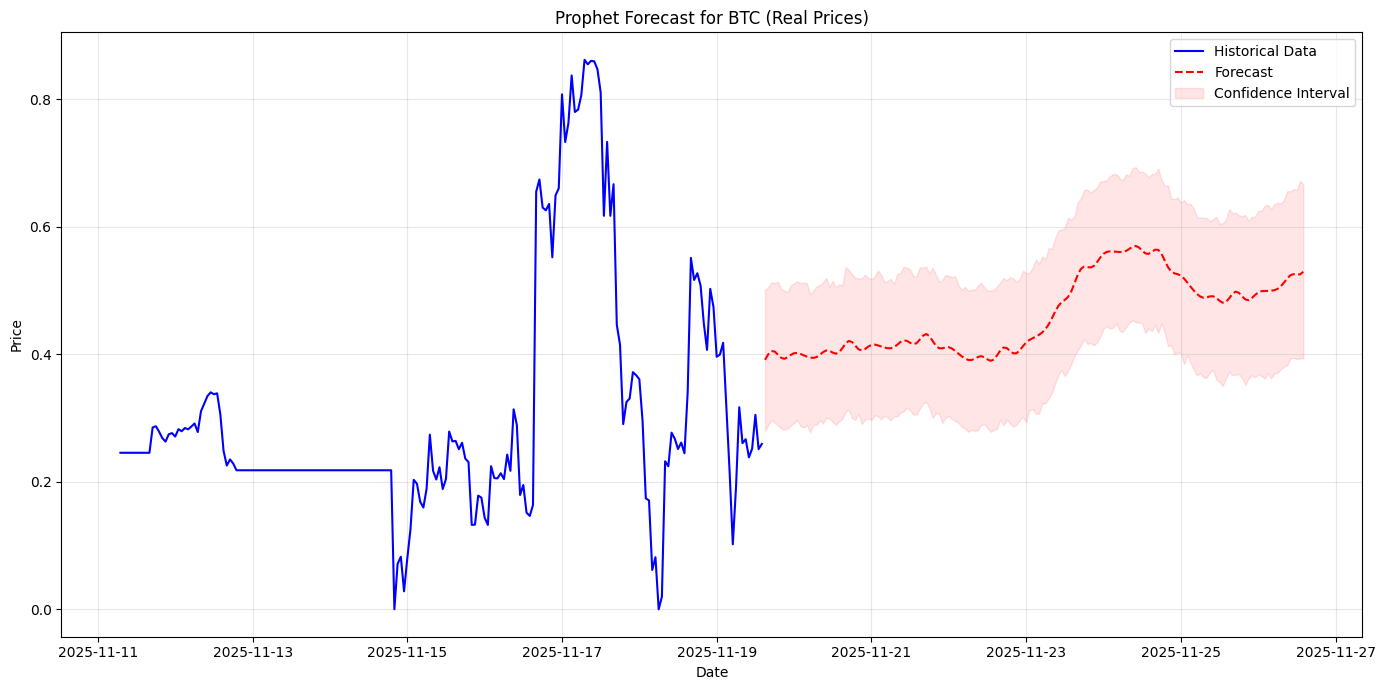

In [5]:
# Visualize
print("--- Plotting Results ---")
plt.figure(figsize=(14, 7))

# Plot History (Last 200 hours for clarity)
history_to_plot = df_recent.tail(200)
plt.plot(history_to_plot.index, history_to_plot['close'], label='Historical Data', color='blue')

# Plot Forecast
# Prophet returns 'ds' (date) 'yhat' (prediction) 'yhat_lower' 'yhat_upper'
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='red', linestyle='--')

# Plot Confidence Interval (Uncertainty)
plt.fill_between(forecast['ds'], 
                 forecast['yhat_lower'], 
                 forecast['yhat_upper'], 
                 color='red', alpha=0.1, label='Confidence Interval')

plt.title(f'Prophet Forecast for {SYMBOL} (Real Prices)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()